# **Exploratory Data Analysis (EDA)**

## Objectives

The objectives of this notebook are to:

- Explore the cleaned Premier League player dataset.
- Understand the distribution of player statistics.
- Investigate relationships between features.
- Explore the target variable.
- Identify features that may contribute to accurately classifying Premier League players as high goal scorers.
- Identify potential data leakage and highly correlated features.
- Summarise the findings to inform the machine learning stage.


## Inputs

- `data/processed/all_players_cleaned.csv`

## Outputs

- Summary statistics
- Visualisations of feature distributions
- Target variable analysis
- Correlation analysis
- Feature selection recommendations
- Evidence to support model development

## Additional Comments

The purpose of this notebook is exploratory rather than corrective. No data cleaning is performed unless a previously unidentified issue is discovered. The analysis focuses on understanding the characteristics of the cleaned dataset and identifying features suitable for predictive modelling.

---

### Change working directory

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\code\\premier-league-predictor\\premier-league-predictor\\jupyter_notebooks'

In [2]:
os.chdir(r"C:\code\premier-league-predictor\premier-league-predictor")
print("You set a new current directory")

You set a new current directory


In [3]:
current_dir = os.getcwd()
current_dir

'C:\\code\\premier-league-predictor\\premier-league-predictor'

### Import packages

All data loading and inspection in this notebook uses `pandas`. No additional libraries are needed at this stage.

In [4]:

import pandas as pd

## Load processed dataset

The cleaned dataset created during the data preparation stage is loaded from the `data/processed` directory for exploratory data analysis.

In [5]:
data_path = "data/processed"
file_path = os.path.join(data_path, "all_players_cleaned.csv")

df = pd.read_csv(file_path)

## Inspect dataset

The dataset is inspected to confirm it has loaded correctly and to obtain an initial understanding of its size, structure and data types before exploratory analysis begins.

In [6]:
df.shape


(8196, 54)

In [7]:
df.head()

,Name,Position,Appearances,Clean sheets,Goals conceded,Tackles,Tackle success %,Last man tackles,Blocked shots,Interceptions,...,Big chances missed,Saves,Penalties saved,Punches,High Claims,Catches,Sweeper clearances,Throw outs,Goal Kicks,Season
0,Rolando Aarons,Midfielder,10,NaN,NaN,13.0,77.0,NaN,0.0,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2015-16
1,Almen Abdi,Midfielder,32,NaN,NaN,83.0,78.0,NaN,10.0,32.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2015-16
2,Abdul Rahman Baba,Defender,15,2.0,13.0,47.0,83.0,0.0,1.0,23.0,...,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2015-16
3,Mehdi Abeid,Midfielder,0,NaN,NaN,0.0,0.0,NaN,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2015-16
4,Tammy Abraham,Forward,2,NaN,NaN,0.0,NaN,NaN,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2015-16


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8196 entries, 0 to 8195
Data columns (total 54 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Name                    8196 non-null   object 
 1   Position                8196 non-null   object 
 2   Appearances             8196 non-null   int64  
 3   Clean sheets            3577 non-null   float64
 4   Goals conceded          3577 non-null   float64
 5   Tackles                 7235 non-null   float64
 6   Tackle success %        5523 non-null   float64
 7   Last man tackles        2616 non-null   float64
 8   Blocked shots           7235 non-null   float64
 9   Interceptions           7235 non-null   float64
 10  Clearances              7235 non-null   float64
 11  Headed Clearance        7235 non-null   float64
 12  Clearances off line     2616 non-null   float64
 13  Recoveries              5523 non-null   float64
 14  Duels won               5523 non-null   

### Generate summary statistics

In [9]:
df.describe(include='all')

,Name,Position,Appearances,Clean sheets,Goals conceded,Tackles,Tackle success %,Last man tackles,Blocked shots,Interceptions,...,Big chances missed,Saves,Penalties saved,Punches,High Claims,Catches,Sweeper clearances,Throw outs,Goal Kicks,Season
count,8196,8196,8196.000000,3577.000000,3577.000000,7235.000000,5523.000000,2616.000000,7235.000000,7235.000000,...,4619.000000,8196.000000,8196.000000,8196.000000,8196.000000,8196.000000,8196.000000,8196.000000,8196.000000,8196
unique,3718,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9
top,Alex Oxlade-Chamberlain,Midfielder,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-23
freq,6,2877,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1086
mean,NaN,NaN,10.952050,2.259435,12.599105,15.046026,33.107550,0.149465,3.113476,9.929648,...,1.327993,2.366398,0.015617,0.337482,0.616642,0.180332,0.405076,3.450220,5.917033,NaN
std,NaN,NaN,13.269553,3.752823,17.605936,22.532904,33.615624,0.470368,5.736301,16.606511,...,3.001591,14.510675,0.153861,2.301140,4.133015,1.282894,2.786947,21.588437,36.064425,NaN
min,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,NaN,NaN,2.000000,0.000000,0.000000,2.000000,39.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
75%,NaN,NaN,23.000000,4.000000,24.000000,24.000000,63.000000,0.000000,4.000000,14.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN


In [10]:
df["Position"].value_counts()

Position
Midfielder    2877
Defender      2634
Forward       1724
Goalkeeper     961
Name: count, dtype: int64

### Position distribution

The dataset contains player-season observations from four playing positions. Midfielders represent the largest proportion of the dataset, followed closely by defenders, then forwards and goalkeepers.

This distribution is expected because football teams can only field one goalkeeper, and many formations also include a greater number of defenders and midfielders than forwards. As a result, the dataset naturally contains more midfielder observations across the nine Premier League seasons.

In [11]:
df["Position"].value_counts(normalize=True) * 100

Position
Midfielder    35.102489
Defender      32.137628
Forward       21.034651
Goalkeeper    11.725232
Name: proportion, dtype: float64

In [12]:
df["Season"].value_counts()

Season
2022-23    1086
2023-24    1016
2021-22     989
2019-20     974
2018-19     882
2020-21     862
2016-17     837
2017-18     793
2015-16     757
Name: count, dtype: int64

## Explore the target variable

Before creating the target variable for the classification model, the distribution of goals is explored. This helps determine whether a threshold of 10 or more goals is an appropriate definition of a high goal scorer and ensures the classification target is supported by the underlying data.

In [13]:
df["Goals"].value_counts().sort_index()

Goals
0     5925
1      804
2      430
3      240
4      176
5      134
6      102
7       74
8       59
9       40
10      52
11      34
12      22
13      20
14      10
15      14
16      11
17       9
18       7
19       5
20       4
21       3
22       7
23       4
24       3
25       2
27       1
30       2
32       1
36       1
Name: count, dtype: int64

In [14]:
((df["Goals"] >=7) & (df["Goals"] <=9)).sum()

np.int64(173)

In [15]:
df[df["Goals"] >= 10]

,Name,Position,Appearances,Clean sheets,Goals conceded,Tackles,Tackle success %,Last man tackles,Blocked shots,Interceptions,...,Big chances missed,Saves,Penalties saved,Punches,High Claims,Catches,Sweeper clearances,Throw outs,Goal Kicks,Season
11,Sergio Agüero,Forward,30,NaN,NaN,15.0,NaN,NaN,26.0,6.0,...,16.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2015-16
22,Dele Alli,Midfielder,33,NaN,NaN,71.0,75.0,NaN,27.0,61.0,...,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2015-16
39,Marko Arnautovic,Forward,34,NaN,NaN,53.0,NaN,NaN,12.0,28.0,...,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2015-16
179,Troy Deeney,Forward,38,NaN,NaN,49.0,NaN,NaN,34.0,17.0,...,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2015-16
180,Jermain Defoe,Forward,33,NaN,NaN,17.0,NaN,NaN,26.0,2.0,...,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2015-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8050,Son Heung-Min,Forward,35,NaN,NaN,21.0,NaN,NaN,22.0,8.0,...,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-24
8104,Leandro Trossard,Forward,34,NaN,NaN,27.0,NaN,NaN,19.0,8.0,...,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-24
8145,Ollie Watkins,Forward,37,NaN,NaN,12.0,NaN,NaN,21.0,4.0,...,22.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-24
8169,Yoane Wissa,Midfielder,34,NaN,NaN,28.0,57.0,NaN,15.0,9.0,...,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-24


In [16]:
df[df["Goals"] >= 10].groupby("Position").size()

Position
Forward       174
Midfielder     38
dtype: int64

Text(0, 0.5, 'Number of Player-Seasons')

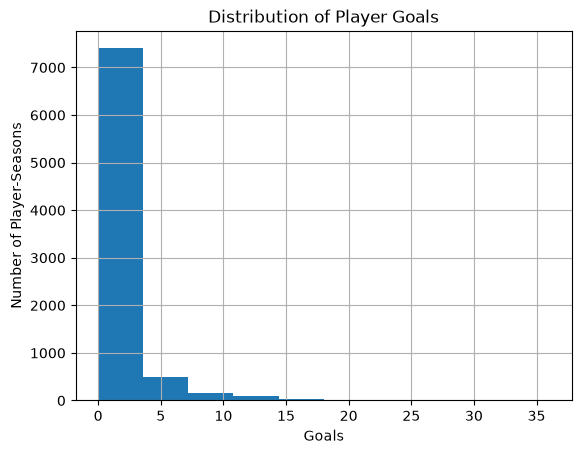

In [17]:
ax = df["Goals"].hist(bins=10)

ax.set_title("Distribution of Player Goals")
ax.set_xlabel("Goals")
ax.set_ylabel("Number of Player-Seasons")

In [18]:
(df["Goals"] >= 10).mean() * 100

np.float64(2.5866276232308443)

### Target Variable Observations

The goal distribution is heavily weighted towards lower goal totals, with the majority of player-season observations recording few or no goals.

Using a threshold of **10 or more goals**, 212 player-season observations would be classified as high goal scorers. This represents approximately **2.6% of the dataset**, indicating a significant class imbalance between high and non-high goal scorers.

When the high-scoring observations were grouped by position, **174 were forwards and 38 were midfielders**. No defenders or goalkeepers scored 10 or more goals during the seasons included in the dataset. This demonstrates that playing position is likely to have an important relationship with the target variable.

The class imbalance will need to be considered during model development, as accuracy alone may provide a misleading measure of model performance.

***

## Explore Potential Predictor Features

The next stage of the analysis investigates player statistics that may help distinguish high goal scorers from non-high goal scorers. Features will be explored based on their relevance to attacking performance and their potential relationship with the target variable.

In [19]:
df.columns.tolist()

['Name',
 'Position',
 'Appearances',
 'Clean sheets',
 'Goals conceded',
 'Tackles',
 'Tackle success %',
 'Last man tackles',
 'Blocked shots',
 'Interceptions',
 'Clearances',
 'Headed Clearance',
 'Clearances off line',
 'Recoveries',
 'Duels won',
 'Duels lost',
 'Successful 50/50s',
 'Aerial battles won',
 'Aerial battles lost',
 'Own goals',
 'Errors leading to goal',
 'Assists',
 'Passes',
 'Passes per match',
 'Big chances created',
 'Crosses',
 'Cross accuracy %',
 'Through balls',
 'Accurate long balls',
 'Yellow cards',
 'Red cards',
 'Fouls',
 'Offsides',
 'Goals',
 'Headed goals',
 'Goals with right foot',
 'Goals with left foot',
 'Hit woodwork',
 'Goals per match',
 'Penalties scored',
 'Freekicks scored',
 'Shots',
 'Shots on target',
 'Shooting accuracy %',
 'Big chances missed',
 'Saves',
 'Penalties saved',
 'Punches',
 'High Claims',
 'Catches',
 'Sweeper clearances',
 'Throw outs',
 'Goal Kicks',
 'Season']

In [20]:
df["HighScorer"] = df["Goals"] >= 10
df["HighScorer"].value_counts()


HighScorer
False    7984
True      212
Name: count, dtype: int64

In [21]:
df.groupby("HighScorer")["Blocked shots"].agg(["mean", "median"])


,mean,median
HighScorer,,
False,2.603446,0.0
True,20.009434,19.0


In [22]:
df["Blocked shots"].isna().mean() * 100

np.float64(11.725231820400195)

In [23]:
df[["Blocked shots", "Shots"]].corr(method="spearman")

,Blocked shots,Shots
Blocked shots,1.000000,0.963762
Shots,0.963762,1.000000


In [24]:
df.groupby("HighScorer")[["Shots", "Shots on target", "Shooting accuracy %", "Appearances"]].agg(["mean", "median"])

Shots        Shots on target        Shooting accuracy %  \
                 mean median            mean median                mean   
HighScorer                                                                
False       11.408214    0.0        3.812798    0.0           15.617881   
True        80.231132   78.5       34.353774   32.5           43.457547   

                  Appearances         
           median        mean median  
HighScorer                            
False         0.0   10.365982    1.0  
True         43.0   33.023585   34.0

### Initial Predictor Observations

Initial comparisons show clear differences between high and non-high goal scorers across several attacking and playing-time features.

- High scorers averaged substantially more **shots** and **shots on target** than non-high scorers.
- High scorers also had a considerably higher average **shooting accuracy**, suggesting that they not only attempt more shots but also direct a greater proportion of them on target.
- High scorers averaged approximately **33 appearances**, compared with approximately **10 appearances** for non-high scorers. This suggests that playing time may be important, as players making more appearances have more opportunities to score.
- The mean and median values for high scorers were relatively similar, while large differences were observed for non-high scorers. This indicates that the non-high-scorer distributions are strongly skewed, with many player-season observations recording very low attacking activity and appearances.
- `Shots`, `Shots on target` and `Shooting accuracy %` may contain overlapping information and should be investigated further before feature selection.
- Missing values remain within the shooting statistics, so these comparisons are based only on the available values for each feature.

Text(0, 0.5, 'Number of Player-Seasons')

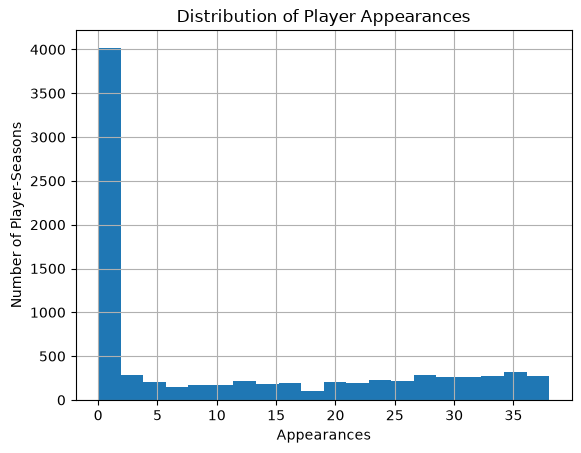

In [25]:
ax = df["Appearances"].hist(bins=20)

ax.set_title("Distribution of Player Appearances")
ax.set_xlabel("Appearances")
ax.set_ylabel("Number of Player-Seasons")

In [26]:
df["Appearances"].value_counts().sort_index()

Appearances
0     3729
1      288
2      157
3      125
4      109
5       96
6       75
7       77
8       89
9       84
10      80
11      93
12     106
13     107
14      87
15      96
16     103
17      89
18      98
19     105
20     102
21     103
22      94
23      96
24     127
25     110
26     102
27     135
28     146
29     128
30     130
31     140
32     118
33     148
34     127
35     160
36     162
37     125
38     150
Name: count, dtype: int64

In [27]:
df[df["Appearances"] > 38][
    ["Name", "Position", "Appearances", "Goals", "Season"]
]

,Name,Position,Appearances,Goals,Season


In [28]:
((df["Appearances"] == 0) & (df["Goals"] > 0)).sum()

np.int64(0)

### Appearance Distribution Observations

The distribution of player appearances shows that a large proportion of player-season records contain very few appearances. This helps explain the difference observed between the mean and median number of appearances for non-high scorers.

During the initial exploratory analysis, four records were identified with more than 38 appearances in a single season. As Premier League clubs play a maximum of 38 league matches per season, these records were inconsistent with the expected season-level data.

Inspection of these records also identified potentially inconsistent goal totals, suggesting that the issue affected the complete player records rather than the `Appearances` feature alone.

No records were found where a player had zero appearances but had scored one or more goals.

The four invalid records were subsequently removed in the data cleaning notebook, and the cleaned dataset was regenerated before continuing the exploratory analysis.

***

### Further Predictor Analysis

Additional player statistics are explored to identify features that may help distinguish high goal scorers from non-high goal scorers. Features are selected based on their relevance to attacking involvement and playing performance.

In [29]:
attacking_columns = [
    "Assists",
    "Big chances created",
    "Big chances missed",
    "Hit woodwork",
    "Offsides"
]

In [30]:
df.groupby("HighScorer")[attacking_columns].agg(["mean", "median"])

Assists        Big chances created        Big chances missed  \
                mean median                mean median               mean   
HighScorer                                                                  
False       0.643412    0.0            0.935746    0.0           0.919446   
True        5.122642    5.0            7.339623    7.0           9.820755   

                  Hit woodwork          Offsides         
           median         mean median       mean median  
HighScorer                                               
False         0.0     0.205035    0.0   1.191229    0.0  
True          8.0     2.372642    2.0  16.259434   15.0

In [31]:
attacking_stats_means = df.groupby("HighScorer")[attacking_columns].mean()


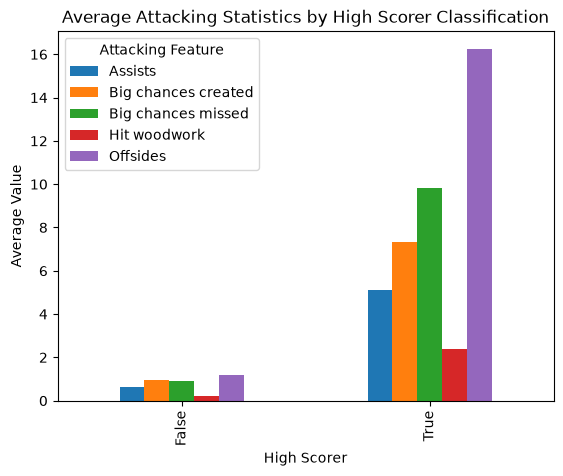

In [32]:
ax = attacking_stats_means.plot(kind="bar")

ax.set_title("Average Attacking Statistics by High Scorer Classification")
ax.set_xlabel("High Scorer")
ax.set_ylabel("Average Value")
ax.legend(title="Attacking Feature")

### Attacking Feature Observations

The comparison shows clear differences in attacking statistics between high and non-high goal scorers.

- High scorers recorded substantially higher mean and median values across all five attacking features investigated.
- High scorers recorded more **assists** and created more **big chances**, indicating greater overall attacking involvement.
- High scorers also missed considerably more **big chances**. Although this represents missed opportunities, it may indicate that high scorers are more frequently involved in goal-scoring situations.
- **Hit woodwork** and **offsides** were also considerably higher among high scorers, potentially reflecting greater involvement in attacking areas rather than necessarily better performance.
- Median values for non-high scorers were zero across all five features, while the corresponding medians for high scorers were substantially higher.
- The visual comparison reinforces the differences observed in the summary statistics, suggesting that these attacking statistics may be useful candidate predictors.
- The relationships between these variables and other potential predictors should be investigated before final feature selection.

Further investigation of `Blocked shots` identified a substantial difference between the two target classes. High scorers recorded approximately **20 blocked shots on average**, compared with approximately **2.6** for non-high scorers, with median values of **19** and **0** respectively.

`Blocked shots` contained approximately **11.7% missing values** and showed a very strong positive Spearman correlation of approximately **0.96** with `Shots`. This suggests that it may be a useful indicator of attacking involvement, although the two features contain substantial overlapping information. This will be considered during feature selection.

***

### Position and High Scorer Classification

Playing position is investigated to determine whether the proportion of high scorers differs between positional groups.

In [33]:
df.groupby("Position")["HighScorer"].mean() * 100

Position
Defender       0.000000
Forward       10.092807
Goalkeeper     0.000000
Midfielder     1.320820
Name: HighScorer, dtype: float64

In [34]:
high_scorer_by_position = df.groupby("Position")["HighScorer"].mean() * 100

Text(0, 0.5, 'High Scorers (%)')

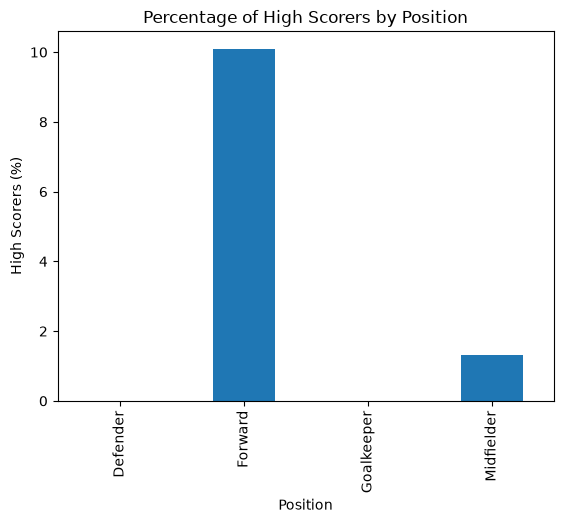

In [35]:
ax = high_scorer_by_position.plot(kind="bar")

ax.set_title("Percentage of High Scorers by Position")
ax.set_xlabel("Position")
ax.set_ylabel("High Scorers (%)")

### Position Observations

Playing position shows a clear relationship with high scorer classification.

- Approximately **10.1% of forward player-season observations** were classified as high scorers.
- Approximately **1.3% of midfielder observations** were classified as high scorers.
- No defender or goalkeeper observations met the high scorer threshold.
- The difference between positional groups suggests that `Position` may be an important categorical predictor when developing the classification model.

***

### Correlation Analysis

Correlation analysis is used to investigate relationships between numerical features and identify variables that may contain similar information.

Spearman correlation is used because several of the investigated features have skewed distributions and contain many low or zero values. This allows relationships to be assessed based on the ranked values rather than assuming a linear relationship between the variables.

In [36]:
correlation_columns = [
    "Shots",
    "Shots on target",
    "Shooting accuracy %",
    "Appearances",
    "Assists",
    "Big chances created",
    "Big chances missed",
    "Hit woodwork",
    "Offsides"
]

In [37]:
df[correlation_columns].corr(method='spearman')

,Shots,Shots on target,Shooting accuracy %,Appearances,Assists,Big chances created,Big chances missed,Hit woodwork,Offsides
Shots,1.000000,0.964313,0.855319,0.948636,0.808497,0.843880,0.820107,0.661404,0.809781
Shots on target,0.964313,1.000000,0.921439,0.905125,0.805703,0.841279,0.840124,0.661644,0.823852
Shooting accuracy %,0.855319,0.921439,1.000000,0.807648,0.667427,0.705239,0.730406,0.522355,0.721859
Appearances,0.948636,0.905125,0.807648,1.000000,0.692777,0.730967,0.742061,0.517708,0.707292
Assists,0.808497,0.805703,0.667427,0.692777,1.000000,0.826865,0.687135,0.529213,0.649427
Big chances created,0.843880,0.841279,0.705239,0.730967,0.826865,1.000000,0.716219,0.550125,0.677347
Big chances missed,0.820107,0.840124,0.730406,0.742061,0.687135,0.716219,1.000000,0.620057,0.786070
Hit woodwork,0.661404,0.661644,0.522355,0.517708,0.529213,0.550125,0.620057,1.000000,0.521705
Offsides,0.809781,0.823852,0.721859,0.707292,0.649427,0.677347,0.786070,0.521705,1.000000


In [38]:
import seaborn as sns
correlation_matrix = df[correlation_columns].corr(method="spearman")

Text(0.5, 1.0, 'Spearman Correlation Between Potential Predictor Features')

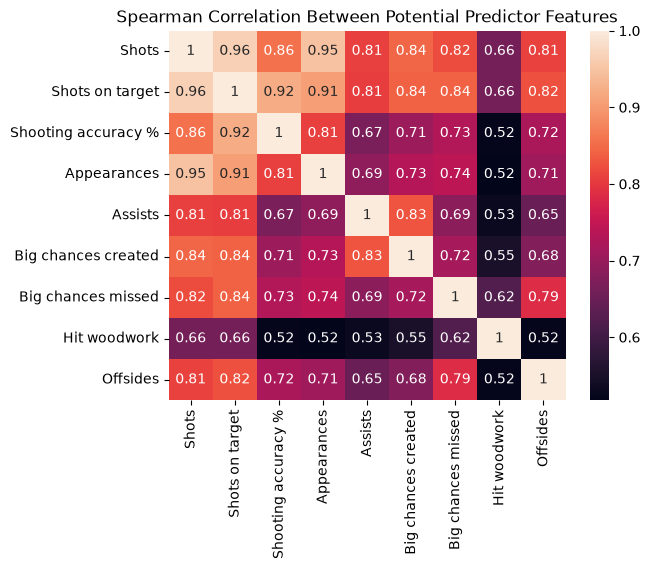

In [39]:
ax = sns.heatmap(correlation_matrix, annot=True)
ax.set_title("Spearman Correlation Between Potential Predictor Features")

### Correlation Observations

The Spearman correlation analysis identified several strong positive relationships between the potential predictor features.

- `Shots` and `Shots on target` showed a very strong positive correlation of approximately **0.96**, indicating substantial overlap between these features.
- `Shots` and `Appearances` were also strongly correlated at approximately **0.95**, supporting the observation that players making more appearances have greater opportunities to take shots.
- `Shots on target` and `Shooting accuracy %` showed a strong positive correlation of approximately **0.92**.
- Several of the other attacking statistics were also strongly correlated, suggesting that multiple features may contain similar information about a player's attacking involvement.
- These relationships should be considered during feature selection to avoid unnecessarily including highly overlapping predictors.

***

### High Scorer Distribution by Season

The distribution of high scorers across seasons is investigated to determine whether the target class remains reasonably consistent over time or varies substantially between seasons.

In [40]:
high_scorers_by_season = df.groupby("Season")["HighScorer"].mean() * 100


Text(0, 0.5, 'High Scorers (%)')

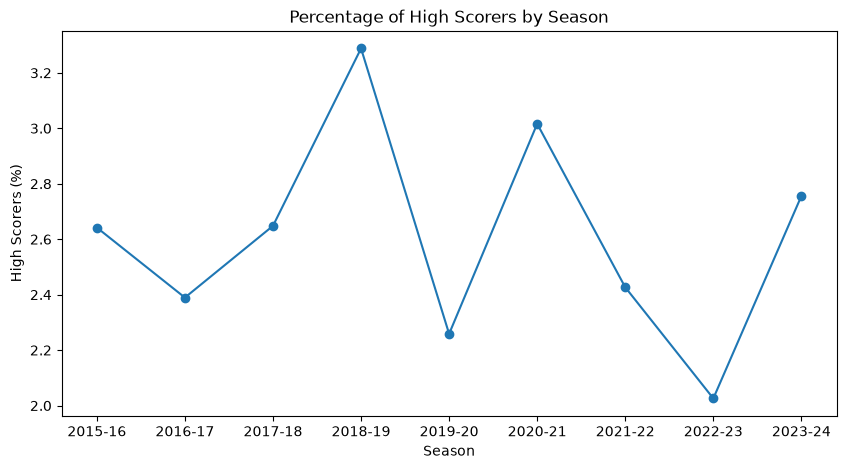

In [41]:
ax = high_scorers_by_season.plot(kind="line", marker="o", figsize=(10, 5))

ax.set_title("Percentage of High Scorers by Season")
ax.set_xlabel("Season")
ax.set_ylabel("High Scorers (%)")

### Seasonal Distribution Observations

The proportion of high scorers remains relatively consistent across the seasons included in the dataset.

- The percentage of high scorers ranges from approximately **2.0% to 3.3%** across the nine seasons.
- The highest proportion was observed in **2018-19**, at approximately **3.3%**.
- The lowest proportion was observed in **2022-23**, at approximately **2.0%**.
- Although some seasonal variation is present, no season shows a substantially different proportion of high scorers compared with the others.
- This suggests that the class imbalance identified in the target variable is relatively consistent across seasons rather than being driven by a particular season.

***

### Missing Values in Potential Predictors

Missing values within the potential predictor features are investigated to understand their extent and determine whether they may require treatment during feature engineering and model development.

In [42]:
df[correlation_columns].isna().sum()

Shots                  3577
Shots on target        3577
Shooting accuracy %    3577
Appearances               0
Assists                   0
Big chances created       0
Big chances missed     3577
Hit woodwork              0
Offsides                961
dtype: int64

In [43]:
df[correlation_columns].isna().mean() * 100

Shots                  43.643241
Shots on target        43.643241
Shooting accuracy %    43.643241
Appearances             0.000000
Assists                 0.000000
Big chances created     0.000000
Big chances missed     43.643241
Hit woodwork            0.000000
Offsides               11.725232
dtype: float64

In [44]:
(df["Shots"].isna() & df["Shots on target"].isna()).sum()

np.int64(3577)

In [45]:
df.groupby("Season")["Shots"].count()

Season
2015-16    435
2016-17    476
2017-18    453
2018-19    495
2019-20    560
2020-21    482
2021-22    547
2022-23    603
2023-24    568
Name: Shots, dtype: int64

In [46]:
missing_shots = df[df["Shots"].isna()]

In [47]:
missing_shots.groupby("Position").size()


Position
Defender      2608
Goalkeeper     961
Midfielder       8
dtype: int64

In [48]:
missing_shots_by_position = missing_shots.groupby("Position").size()

Text(0, 0.5, 'Number of Missing Records')

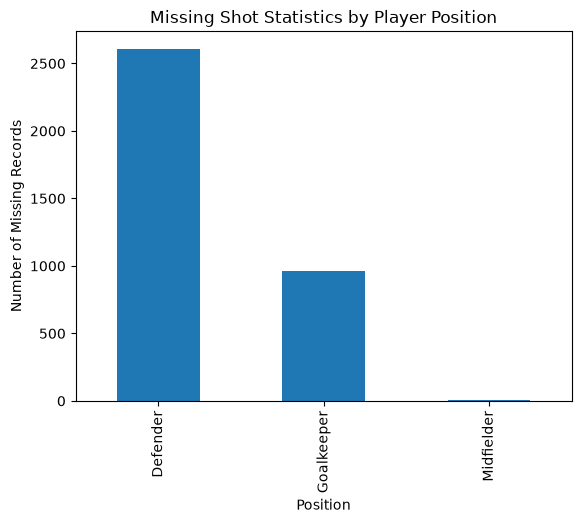

In [49]:
ax = missing_shots_by_position.plot(kind="bar")

ax.set_title("Missing Shot Statistics by Player Position")
ax.set_xlabel("Position")
ax.set_ylabel("Number of Missing Records")

In [50]:
shooting_columns = [
    "Shots",
    "Shots on target",
    "Shooting accuracy %",
    "Big chances missed"
]

In [51]:
df[shooting_columns].isna().all(axis=1).sum()

np.int64(3577)

### Missing Predictor Observations

Missing values were identified within several of the potential predictor features.

- `Shots`, `Shots on target`, `Shooting accuracy %` and `Big chances missed` each contain approximately **43.6% missing values**.
- Investigation confirmed that the same **3,577 player-season records** are missing all four of these shooting statistics.
- The missing shooting statistics are strongly associated with playing position, with **2,608 defenders**, **961 goalkeepers** and only **8 midfielders** affected. No forwards had missing `Shots` values.
- Non-missing `Shots` values were present across all seasons, suggesting that the missingness is not isolated to particular seasons.
- `Offsides` contains approximately **11.7% missing values**, while the other investigated predictor features contain no missing values.
- As the missingness follows a clear pattern, missing values should not automatically be treated as zero. An appropriate strategy will be considered during feature engineering and model development.

***

### Passing and Creative Features

Passing and creative statistics are investigated to determine whether high goal scorers demonstrate different patterns of involvement in possession and attacking build-up compared with non-high scorers.

In [52]:
passing_columns = [
    "Passes",
    "Passes per match",
    "Crosses",
    "Cross accuracy %",
    "Through balls"
]

In [53]:
df.groupby("HighScorer")[passing_columns].agg(["mean", "median"])

Passes        Passes per match           Crosses         \
                  mean median             mean median       mean median   
HighScorer                                                                
False       344.877881   10.0        15.231418   4.50  15.324932    0.0   
True        860.764151  773.0        25.821179  23.49  50.415094   34.0   

           Cross accuracy %        Through balls         
                       mean median          mean median  
HighScorer                                               
False             10.188252    0.0      1.099781    0.0  
True              21.926829   23.0     10.853659   10.0

In [54]:
passing_plot_columns = [
    "Passes per match",
    "Crosses",
    "Cross accuracy %",
    "Through balls"
]

In [55]:
passing_stats_means = df.groupby("HighScorer")[passing_plot_columns].mean()

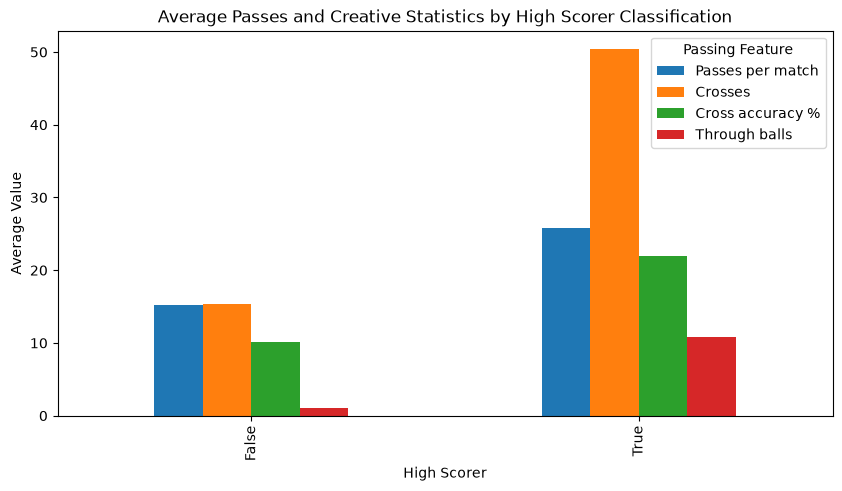

In [56]:
ax = passing_stats_means.plot(
    kind="bar",
    figsize=(10, 5)
)
ax.set_title("Average Passes and Creative Statistics by High Scorer Classification")
ax.set_xlabel("High Scorer")
ax.set_ylabel("Average Value")
ax.legend(title="Passing Feature")

### Passing and Creative Feature Observations

The analysis shows clear differences in passing and creative statistics between high and non-high scorers.

- High scorers recorded substantially more **passes** overall and also completed more **passes per match**, suggesting greater involvement in possession.
- High scorers recorded considerably more **crosses** and a higher **cross accuracy percentage**.
- **Through balls** also showed a substantial difference between the two groups, with high scorers recording much higher mean and median values.
- The differences remain visible when considering `Passes per match`, suggesting that the higher passing involvement of high scorers is not explained solely by their greater number of appearances.
- These results suggest that passing and creative statistics may provide useful additional predictors alongside the attacking features already investigated.
- Further feature selection will be required before modelling, particularly because some variables may contain overlapping information.

***

### Player Involvement Features

Player involvement statistics are investigated to determine whether high goal scorers demonstrate different patterns in duels, recoveries and aerial involvement compared with non-high scorers.

In [57]:
involvement_columns = [
    "Recoveries",
    "Duels won",
    "Duels lost",
    "Successful 50/50s",
    "Aerial battles won",
    "Aerial battles lost"
]

In [58]:
df.groupby("HighScorer")[involvement_columns].agg(["mean", "median"])

Recoveries          Duels won         Duels lost         \
                  mean median        mean median        mean median   
HighScorer                                                            
False        50.655965    5.5   46.024626    6.0   40.929953    6.0   
True        144.146341  132.0  147.731707  142.0  171.048780  163.0   

           Successful 50/50s        Aerial battles won         \
                        mean median               mean median   
HighScorer                                                      
False               6.893652    0.0          14.442904    1.0   
True               39.487805   38.0          29.146341   17.0   

           Aerial battles lost         
                          mean median  
HighScorer                             
False                12.220175    1.0  
True                 37.804878   27.0

### Player Involvement Observations

High scorers recorded substantially higher mean and median values across all of the investigated player involvement statistics.

However, these features represent cumulative season totals and high scorers were previously found to make considerably more appearances than non-high scorers. Greater values may therefore partly reflect increased playing time and opportunity rather than a direct relationship with goal-scoring ability.

This interpretation is supported by high scorers recording substantially higher values for both `Duels won` and `Duels lost`, indicating greater overall involvement rather than simply greater success in duels.

These features may contain useful information, but their relationship with playing time should be considered during feature selection and feature engineering.

***

## Exploratory Data Analysis Conclusions

The exploratory analysis identified several patterns that will inform feature engineering and model development.

### Target Variable

The `HighScorer` target is highly imbalanced. Only approximately **2.6%** of player-season observations are classified as high scorers using the threshold of 10 or more goals. This imbalance will need to be considered when evaluating classification models, as accuracy alone may provide a misleading indication of model performance.

### Playing Position

Playing position showed a clear relationship with the target. Approximately **10.1% of forwards** were classified as high scorers compared with approximately **1.3% of midfielders**, while no defenders or goalkeepers reached the high-scorer threshold. `Position` will therefore be considered as a potential categorical predictor.

### Attacking Features

High scorers recorded substantially greater values across several attacking statistics, including `Shots`, `Shots on target`, `Assists`, `Big chances created`, `Big chances missed`, `Hit woodwork`, `Offsides` and `Blocked shots`.

Several of these features are strongly correlated. For example, `Shots` and `Shots on target` showed a Spearman correlation of approximately **0.96**, while `Blocked shots` and `Shots` also showed a correlation of approximately **0.96**. This suggests that some attacking features contain overlapping information and should be considered carefully during feature selection.

### Playing Time and Player Involvement

High scorers made considerably more appearances than non-high scorers. They also recorded higher values across passing, creative and general involvement statistics.

As many of these variables are cumulative season totals, some of these differences may reflect greater playing time and opportunity rather than goal-scoring ability alone. This relationship should be considered during feature engineering.

### Missing Data

Several potentially useful shooting statistics contain substantial missing data. `Shots`, `Shots on target`, `Shooting accuracy %` and `Big chances missed` are missing for approximately **43.6%** of observations.

The same 3,577 observations are missing all four statistics, with the missing records consisting almost entirely of defenders and goalkeepers. This indicates systematic rather than random missingness and will require consideration during feature engineering.

### Season

The proportion of high scorers remained relatively consistent across the nine seasons, ranging from approximately **2.0% to 3.3%**. This suggests that the target imbalance is not being driven by a particular season.

### Next Steps

The findings from the exploratory analysis will be used to guide feature engineering and feature selection. Particular consideration will be given to:

- selecting predictors that provide useful information without directly revealing the target;
- handling the categorical `Position` feature;
- investigating appropriate treatment of missing values;
- considering the effect of cumulative statistics and playing time;
- reducing unnecessary overlap between highly correlated predictors;
- preparing the final feature set for classification modelling.